## Case Study Assignment 1
**Name:** Chloe Barker  
**Course:** DS-7333: Quantifying The World

Your case study is to build linear regression models using L1 and L2 regularization (or both as an additional 3rd model) on the task to predict the Critical Temperature as closely as possible. In addition, include which 10 variables carry the most importance on your best performing models for both L1 and L2

**Required:**
- 2 Logistic Regression Models (L1 and L2) 
- Top 10 Variable importance 
- Visualization of Results 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

In [2]:
train = pd.read_csv('/Users/chloebarker/Downloads/Quantifying the World/Assignment 1/data/train.csv')
unique_m = pd.read_csv('/Users/chloebarker/Downloads/Quantifying the World/Assignment 1/data/unique_m.csv')

In [3]:
print(train.shape)
print(unique_m.shape)

train.head()

(21263, 82)
(21263, 88)


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
# Verify the rows align correctly
match = np.allclose(train['critical_temp'],unique_m['critical_temp'])

print("Critical temperature columns match:", match)

Critical temperature columns match: True


In [5]:
# Remove Duplicate Columns Before Merge
unique_m_clean = unique_m.drop(columns=['critical_temp'])

# Merge the datasets
df = pd.concat([train, unique_m_clean], axis=1)

print(df.shape)

# Remove encoded 'material' column
df = df.drop(columns=['material'])

print(df.shape)

df.head()

(21263, 169)
(21263, 168)


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [6]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

## Train Test Split

In [7]:
# Define features and target
X = df.drop(columns=['critical_temp'])

y = df['critical_temp']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Normalize the Data

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## EDA

### Distribution of Critical Temperature

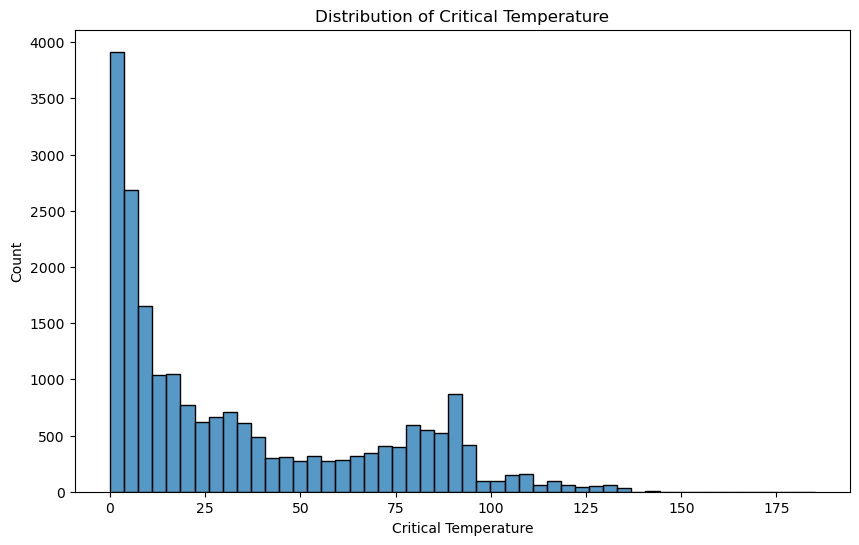

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(y, bins=50)
plt.title('Distribution of Critical Temperature')
plt.xlabel('Critical Temperature')
plt.ylabel('Count')
plt.show()

### Correlation Heatmap

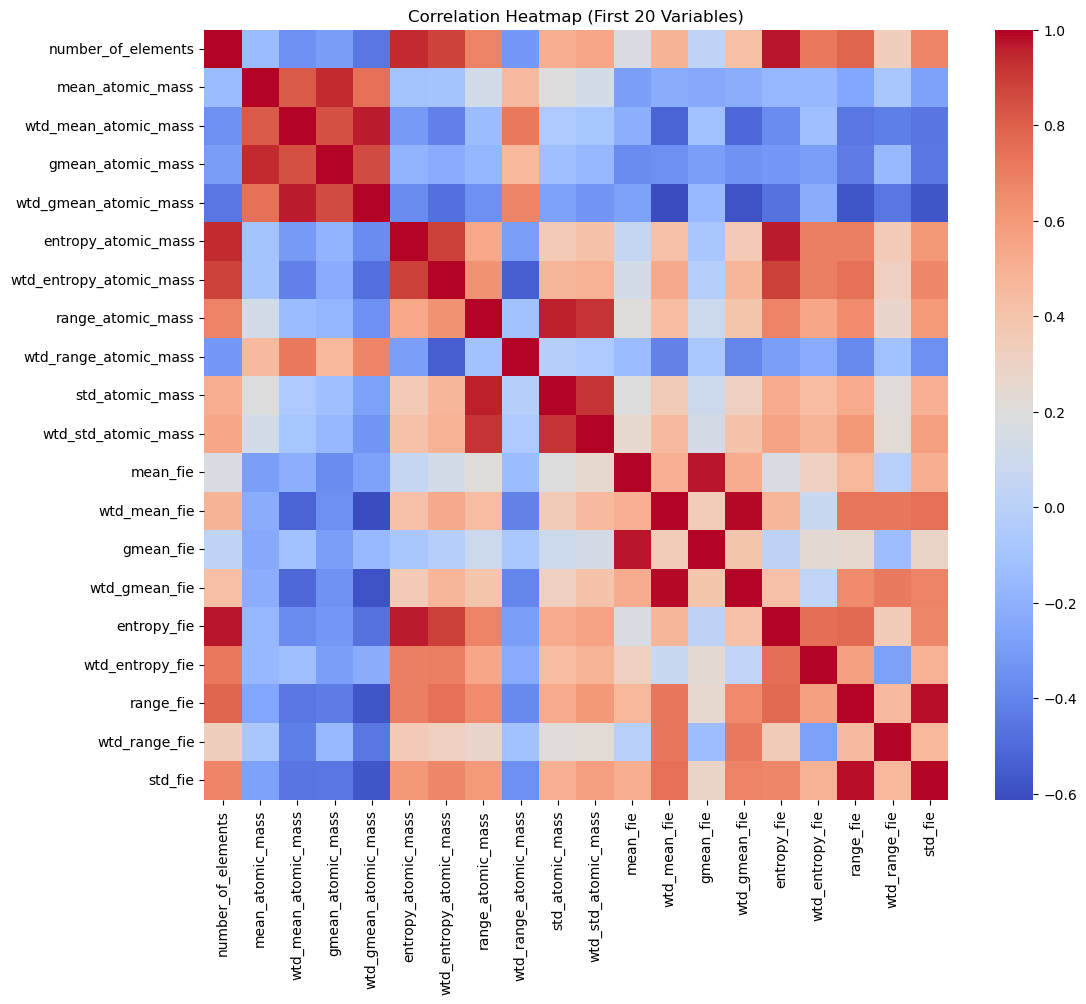

In [11]:
plt.figure(figsize=(12,10))
corr_subset = df.iloc[:, :20].corr()
sns.heatmap(corr_subset, cmap='coolwarm')
plt.title('Correlation Heatmap (First 20 Variables)')
plt.show()

## Linear Regression 1: Lasso

In [12]:
# Train lasso model
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
lasso_preds = lasso_model.predict(X_test_scaled)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.199e+05, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(


In [13]:
lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_preds))

lasso_r2 = r2_score(y_test, lasso_preds)

print("Lasso RMSE:", lasso_rmse)
print("Lasso R^2:", lasso_r2)

Lasso RMSE: 16.515921795426838
Lasso R^2: 0.7630264054770193


## Top 10 Variables: Lasso

In [14]:
lasso_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})

lasso_importance['Abs_Coefficient'] = np.abs(
    lasso_importance['Coefficient']
)

lasso_top10 = lasso_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

lasso_top10

,Feature,Coefficient,Abs_Coefficient
49,std_ElectronAffinity,23.721717,23.721717
62,wtd_mean_ThermalConductivity,21.320546,21.320546
47,range_ElectronAffinity,-19.023818,19.023818
2,wtd_mean_atomic_mass,-16.318956,16.318956
76,wtd_entropy_Valence,-14.708559,14.708559
15,entropy_fie,12.773829,12.773829
17,range_fie,12.696596,12.696596
19,std_fie,-12.483929,12.483929
16,wtd_entropy_fie,12.093934,12.093934
64,wtd_gmean_ThermalConductivity,-12.052722,12.052722


## Linear Regression 2

In [15]:
# Train ridge model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
ridge_preds = ridge_model.predict(X_test_scaled)

In [16]:
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_preds))

ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge RMSE:", ridge_rmse)

print("Ridge R^2:", ridge_r2)

Ridge RMSE: 16.510597631778186
Ridge R^2: 0.7631791650808989


## Top 10 Variables: Ridge

In [17]:
ridge_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})

ridge_importance['Abs_Coefficient'] = np.abs(
    ridge_importance['Coefficient']
)

ridge_top10 = ridge_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

ridge_top10

,Feature,Coefficient,Abs_Coefficient
2,wtd_mean_atomic_mass,-37.161463,37.161463
22,wtd_mean_atomic_radius,34.545474,34.545474
24,wtd_gmean_atomic_radius,-32.867354,32.867354
49,std_ElectronAffinity,26.790209,26.790209
76,wtd_entropy_Valence,-24.789547,24.789547
52,wtd_mean_FusionHeat,-24.318697,24.318697
62,wtd_mean_ThermalConductivity,23.623794,23.623794
1,mean_atomic_mass,22.808192,22.808192
75,entropy_Valence,21.949686,21.949686
4,wtd_gmean_atomic_mass,21.726620,21.726620


## Visualizations of Top 10 Variables

### Lasso Top Variables Plot

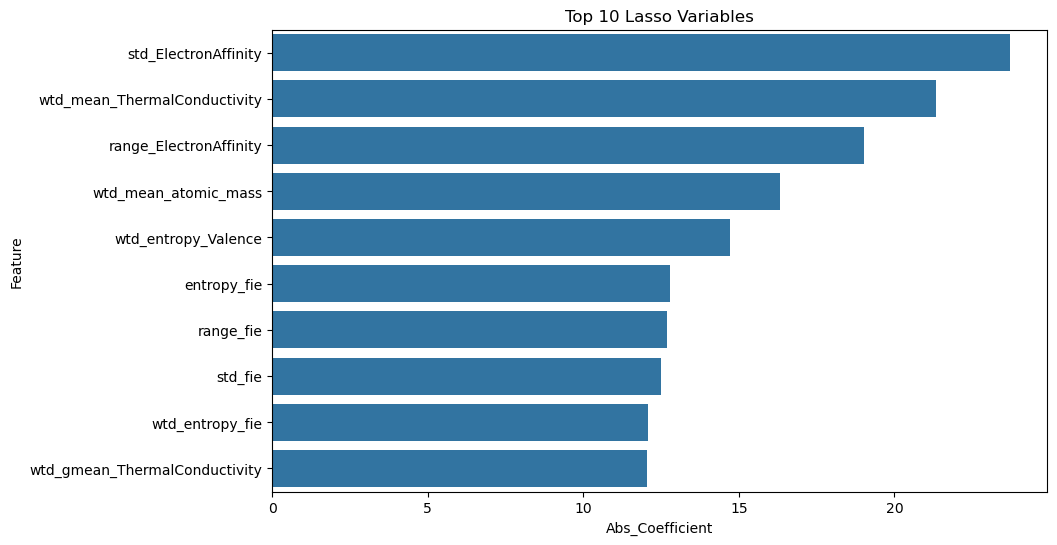

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=lasso_top10,
    x='Abs_Coefficient',
    y='Feature'
)

plt.title('Top 10 Lasso Variables')

plt.show()

### Ridge Top Variables Plot

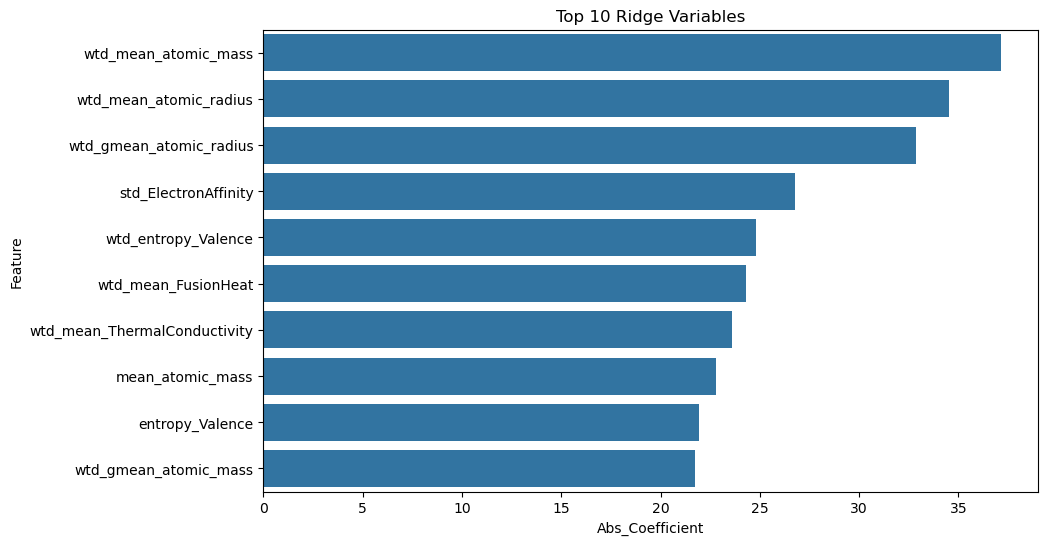

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=ridge_top10,
    x='Abs_Coefficient',
    y='Feature'
)

plt.title('Top 10 Ridge Variables')

plt.show()

## Final Comparison 

In [20]:
results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'RMSE': [ridge_rmse, lasso_rmse],
    'R^2': [ridge_r2, lasso_r2]
})

results

,Model,RMSE,R^2
0,Ridge,16.510598,0.763179
1,Lasso,16.515922,0.763026
